In [2]:
pip install xlrd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Show ALL columns (important for your sir)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_excel("/home/richee/Downloads/Assesment/data/raw/Dataset of health insurance portfolio.xls")

df.head()

,ID,ID_policy,ID_insured,period,date_effect_insured,date_lapse_insured,date_effect_policy,date_lapse_policy,year_effect_insured,year_lapse_insured,...,C_H,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T,C_C
0,1_1,1,1,2017,1993-06-15,2017-12-20,1993-06-15,NaT,1993,2017.0,...,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
1,1_2,1,2,2017,1993-06-15,NaT,1993-06-15,NaT,1993,NaN,...,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
2,2_1,2,1,2017,1993-06-16,NaT,1993-06-16,NaT,1993,NaN,...,H6,100.0,94.0,26.0,11.0,85.0,7.0,1.0,100.0,C6
3,3_3,3,3,2017,1993-06-15,NaT,1993-06-15,NaT,1993,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3_5,3,5,2017,1993-06-15,NaT,1993-06-15,NaT,1993,NaN,...,H6,99.0,81.0,32.0,34.0,69.0,9.0,4.0,98.0,C6


In [4]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Total Rows: 65535
Total Columns: 42


In [7]:
print("\nDataset Info:")
df.info()

print("\n Description: Shows all columns, data types, and missing values.")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    65535 non-null  object        
 1   ID_policy             65535 non-null  int64         
 2   ID_insured            65535 non-null  int64         
 3   period                65535 non-null  int64         
 4   date_effect_insured   65535 non-null  datetime64[ns]
 5   date_lapse_insured    21903 non-null  datetime64[ns]
 6   date_effect_policy    65535 non-null  datetime64[ns]
 7   date_lapse_policy     18818 non-null  datetime64[ns]
 8   year_effect_insured   65535 non-null  int64         
 9   year_lapse_insured    21903 non-null  float64       
 10  year_effect_policy    65535 non-null  int64         
 11  year_lapse_policy     18818 non-null  float64       
 12  exposure_time         65535 non-null  float64       
 13  l

In [10]:
print("\n Missing Values:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("\n Description: Columns with missing data need cleaning.")


 Missing Values:
date_lapse_policy     46717
year_lapse_policy     46717
year_lapse_insured    43632
date_lapse_insured    43632
C_GE_S                 3379
C_GE_T                 3379
C_IE_T                 3379
C_IE_S                 3379
C_IE_P                 3379
C_GE_P                 3379
C_II                   3379
C_GI                   3379
C_H                    2577
IICIMUN                2577
C_C                    2397
IICIPROV                822
dtype: int64

 Description: Columns with missing data need cleaning.


In [11]:
print("\n Statistical Summary:")
display(df.describe())

print("\n Description: Shows mean, min, max, etc. for numerical features.")


 Statistical Summary:


,ID_policy,ID_insured,period,date_effect_insured,date_lapse_insured,date_effect_policy,date_lapse_policy,year_effect_insured,year_lapse_insured,year_effect_policy,year_lapse_policy,exposure_time,lapse,seniority_insured,seniority_policy,age,premium,cost_claims_year,n_medical_services,n_insured_pc,n_insured_mun,n_insured_prov,IICIMUN,IICIPROV,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T
count,65535.000000,65535.000000,65535.0,65535,21903,65535,18818,65535.000000,21903.000000,65535.000000,18818.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,62958.000000,64713.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000
mean,15416.692592,12.067399,2017.0,2002-01-25 23:47:28.523689728,2018-05-19 02:27:04.215860992,2000-11-12 12:34:17.331197056,2018-05-21 21:06:13.047082496,2001.697688,2017.687486,2000.505196,2017.684238,0.923585,2.044694,15.302312,16.494804,47.074907,885.252034,619.868082,15.548684,295.851408,6424.454856,14554.281498,7.559714,4.474528,81.603498,52.364357,49.409132,48.253025,52.352339,19.307066,23.287342,85.805763
min,1.000000,1.000000,2017.0,1933-06-01 00:00:00,2017-01-01 00:00:00,1932-03-01 00:00:00,2017-01-01 00:00:00,1933.000000,2017.000000,1932.000000,2017.000000,0.000000,1.000000,0.000000,0.000000,0.000000,33.330000,0.000000,0.000000,1.000000,1.000000,6.000000,0.006137,0.007458,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,7294.500000,1.000000,2017.0,1994-11-01 00:00:00,2017-12-31 00:00:00,1994-01-01 00:00:00,2017-12-31 00:00:00,1994.000000,2017.000000,1994.000000,2017.000000,1.000000,2.000000,5.000000,6.000000,32.000000,615.060000,0.000000,0.000000,48.000000,113.000000,2909.000000,1.839481,1.285414,77.000000,28.000000,24.000000,24.000000,28.000000,6.000000,2.000000,80.000000
50%,14584.000000,2.000000,2017.0,2004-04-08 00:00:00,2017-12-31 00:00:00,2003-03-27 00:00:00,2017-12-31 00:00:00,2004.000000,2017.000000,2003.000000,2017.000000,1.000000,2.000000,13.000000,14.000000,48.000000,822.120000,199.980000,6.000000,123.000000,1234.000000,7726.000000,7.246377,5.307049,93.000000,54.000000,49.000000,47.000000,54.000000,14.000000,10.000000,95.000000
75%,23539.000000,3.000000,2017.0,2012-01-18 00:00:00,2018-12-31 00:00:00,2011-02-15 00:00:00,2018-12-31 00:00:00,2012.000000,2018.000000,2011.000000,2018.000000,1.000000,2.000000,23.000000,23.000000,65.000000,1015.920000,575.280000,21.000000,432.000000,19315.000000,29465.000000,11.916888,5.307049,98.000000,77.000000,75.000000,72.000000,77.000000,28.000000,38.000000,99.000000
max,31133.000000,1886.000000,2017.0,2017-12-15 00:00:00,2019-12-31 00:00:00,2017-12-15 00:00:00,2019-12-31 00:00:00,2017.000000,2019.000000,2017.000000,2019.000000,1.000000,3.000000,84.000000,85.000000,99.000000,19482.000000,87000.900000,1029.000000,2518.000000,19315.000000,29465.000000,250.000000,10.485931,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
std,9332.940947,98.340249,0.0,NaN,NaN,NaN,NaN,12.504348,0.829823,13.386732,0.828356,0.255062,0.426166,12.504348,13.386732,22.751082,571.061694,1729.198350,25.955000,394.115704,8256.396668,12567.254210,6.707019,2.822656,25.844923,28.636860,28.998658,28.482067,28.746276,17.635048,26.399482,19.147594



 Description: Shows mean, min, max, etc. for numerical features.


In [13]:
print("\nData Types:")
display(df.dtypes.value_counts())

print("\n Description: Helps identify numerical vs categorical columns")


Data Types:


float64           15
int64             13
object            10
datetime64[ns]     4
Name: count, dtype: int64


 Description: Helps identify numerical vs categorical columns


In [14]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
}).sort_values(by="Percentage (%)", ascending=False)

print("\n Missing Values Summary:")
display(missing_df[missing_df["Missing Values"] > 0])

print("\n Description:")
print("Shows missing values count and percentage per column")


 Missing Values Summary:


,Missing Values,Percentage (%)
date_lapse_policy,46717,71.285573
year_lapse_policy,46717,71.285573
year_lapse_insured,43632,66.578164
date_lapse_insured,43632,66.578164
C_GE_S,3379,5.156023
C_GE_T,3379,5.156023
C_IE_T,3379,5.156023
C_IE_S,3379,5.156023
C_IE_P,3379,5.156023
C_GE_P,3379,5.156023



 Description:
Shows missing values count and percentage per column


In [15]:
total_missing = df.isnull().sum().sum()

print("\nTotal Missing Values in Dataset:", total_missing)

print("\nDescription:")
print("Total missing values across entire dataset")


Total Missing Values in Dataset: 216103

Description:
Total missing values across entire dataset


In [16]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("\n Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

print("\nDescription:")
print("Separates features for proper preprocessing")


 Numerical Columns: 28
Categorical Columns: 14

Description:
Separates features for proper preprocessing


In [18]:
print("\n Numerical Summary:")
display(df[num_cols].describe())

print("\n Description:")
print("Shows mean, min, max, std for numeric features")


 Numerical Summary:


,ID_policy,ID_insured,period,year_effect_insured,year_lapse_insured,year_effect_policy,year_lapse_policy,exposure_time,lapse,seniority_insured,seniority_policy,age,premium,cost_claims_year,n_medical_services,n_insured_pc,n_insured_mun,n_insured_prov,IICIMUN,IICIPROV,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T
count,65535.000000,65535.000000,65535.0,65535.000000,21903.000000,65535.000000,18818.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,62958.000000,64713.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000,62156.000000
mean,15416.692592,12.067399,2017.0,2001.697688,2017.687486,2000.505196,2017.684238,0.923585,2.044694,15.302312,16.494804,47.074907,885.252034,619.868082,15.548684,295.851408,6424.454856,14554.281498,7.559714,4.474528,81.603498,52.364357,49.409132,48.253025,52.352339,19.307066,23.287342,85.805763
std,9332.940947,98.340249,0.0,12.504348,0.829823,13.386732,0.828356,0.255062,0.426166,12.504348,13.386732,22.751082,571.061694,1729.198350,25.955000,394.115704,8256.396668,12567.254210,6.707019,2.822656,25.844923,28.636860,28.998658,28.482067,28.746276,17.635048,26.399482,19.147594
min,1.000000,1.000000,2017.0,1933.000000,2017.000000,1932.000000,2017.000000,0.000000,1.000000,0.000000,0.000000,0.000000,33.330000,0.000000,0.000000,1.000000,1.000000,6.000000,0.006137,0.007458,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,7294.500000,1.000000,2017.0,1994.000000,2017.000000,1994.000000,2017.000000,1.000000,2.000000,5.000000,6.000000,32.000000,615.060000,0.000000,0.000000,48.000000,113.000000,2909.000000,1.839481,1.285414,77.000000,28.000000,24.000000,24.000000,28.000000,6.000000,2.000000,80.000000
50%,14584.000000,2.000000,2017.0,2004.000000,2017.000000,2003.000000,2017.000000,1.000000,2.000000,13.000000,14.000000,48.000000,822.120000,199.980000,6.000000,123.000000,1234.000000,7726.000000,7.246377,5.307049,93.000000,54.000000,49.000000,47.000000,54.000000,14.000000,10.000000,95.000000
75%,23539.000000,3.000000,2017.0,2012.000000,2018.000000,2011.000000,2018.000000,1.000000,2.000000,23.000000,23.000000,65.000000,1015.920000,575.280000,21.000000,432.000000,19315.000000,29465.000000,11.916888,5.307049,98.000000,77.000000,75.000000,72.000000,77.000000,28.000000,38.000000,99.000000
max,31133.000000,1886.000000,2017.0,2017.000000,2019.000000,2017.000000,2019.000000,1.000000,3.000000,84.000000,85.000000,99.000000,19482.000000,87000.900000,1029.000000,2518.000000,19315.000000,29465.000000,250.000000,10.485931,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000



 Description:
Shows mean, min, max, std for numeric features


In [ ]:
print("\n Categorical Summary:")
display(df[cat_cols].describe())

print("\n Description:")
print("Shows unique values and frequency")


📊 Categorical Summary:


,date_effect_insured,date_lapse_insured,date_effect_policy,date_lapse_policy
count,65535,21903,65535,18818
mean,2002-01-25 23:47:28.523689728,2018-05-19 02:27:04.215860992,2000-11-12 12:34:17.331197056,2018-05-21 21:06:13.047082496
min,1933-06-01 00:00:00,2017-01-01 00:00:00,1932-03-01 00:00:00,2017-01-01 00:00:00
25%,1994-11-01 00:00:00,2017-12-31 00:00:00,1994-01-01 00:00:00,2017-12-31 00:00:00
50%,2004-04-08 00:00:00,2017-12-31 00:00:00,2003-03-27 00:00:00,2017-12-31 00:00:00
75%,2012-01-18 00:00:00,2018-12-31 00:00:00,2011-02-15 00:00:00,2018-12-31 00:00:00
max,2017-12-15 00:00:00,2019-12-31 00:00:00,2017-12-15 00:00:00,2019-12-31 00:00:00



📌 Description:
Shows unique values and frequency


In [20]:
variance = df[num_cols].var().sort_values()

print("\nFeature Variance:")
display(variance)

print("\n Description:")
print("Low variance features may not be useful for prediction")


Feature Variance:


period                 0.000000e+00
exposure_time          6.505647e-02
lapse                  1.816171e-01
year_lapse_policy      6.861745e-01
year_lapse_insured     6.886056e-01
IICIPROV               7.967388e+00
IICIMUN                4.498410e+01
year_effect_insured    1.563587e+02
seniority_insured      1.563587e+02
year_effect_policy     1.792046e+02
seniority_policy       1.792046e+02
C_GE_P                 3.109949e+02
C_GE_T                 3.666304e+02
age                    5.176117e+02
C_GI                   6.679601e+02
n_medical_services     6.736620e+02
C_GE_S                 6.969326e+02
C_IE_S                 8.112282e+02
C_II                   8.200698e+02
C_IE_T                 8.263484e+02
C_IE_P                 8.409221e+02
ID_insured             9.670805e+03
n_insured_pc           1.553272e+05
premium                3.261115e+05
cost_claims_year       2.990127e+06
n_insured_mun          6.816809e+07
ID_policy              8.710379e+07
n_insured_prov         1.579


 Description:
Low variance features may not be useful for prediction


In [21]:
skewness = df[num_cols].skew().sort_values(ascending=False)

print("\n Skewness of Numerical Features:")
display(skewness)

print("\n Description:")
print("High skewness means data is not normally distributed")


 Skewness of Numerical Features:


ID_insured             14.880963
cost_claims_year       12.128682
IICIMUN                 6.896088
n_medical_services      5.392530
premium                 5.294637
n_insured_pc            2.744507
C_GE_P                  1.502263
seniority_policy        1.468432
seniority_insured       1.330993
C_GE_S                  1.131994
n_insured_mun           0.862263
year_lapse_policy       0.643472
year_lapse_insured      0.636353
IICIPROV                0.374888
n_insured_prov          0.283122
lapse                   0.261687
ID_policy               0.131611
C_IE_S                  0.090923
C_IE_P                  0.058821
period                  0.000000
C_II                   -0.086903
C_IE_T                 -0.089166
age                    -0.227633
year_effect_insured    -1.330993
year_effect_policy     -1.468432
C_GI                   -1.821891
C_GE_T                 -1.914554
exposure_time          -3.165896
dtype: float64


 Description:
High skewness means data is not normally distributed


In [23]:
duplicates = df.duplicated().sum()

print("\n Duplicate Rows:", duplicates)

print("\n Description:")
print("Duplicate data can bias model")


 Duplicate Rows: 0

 Description:
Duplicate data can bias model


In [24]:
print("\n Target Variable: premium")

print("Mean:", df["premium"].mean())
print("Median:", df["premium"].median())
print("Min:", df["premium"].min())
print("Max:", df["premium"].max())

print("\nDescription:")
print("Understanding distribution of target variable")


 Target Variable: premium
Mean: 885.2520343327992
Median: 822.12
Min: 33.33
Max: 19482.0

Description:
Understanding distribution of target variable


In [26]:
corr_target = df[num_cols].corr()["premium"].sort_values(ascending=False)

print("\n Correlation with Target (premium):")
display(corr_target)

print("\n Description:")
print("Shows which features influence premium most")


 Correlation with Target (premium):


premium                1.000000
age                    0.378881
n_medical_services     0.303860
cost_claims_year       0.255348
seniority_insured      0.130725
seniority_policy       0.097004
C_IE_T                 0.073491
C_II                   0.065241
year_lapse_policy      0.048882
C_GE_T                 0.047359
year_lapse_insured     0.046822
exposure_time          0.045339
IICIPROV               0.031333
C_GI                   0.019903
IICIMUN               -0.013326
n_insured_pc          -0.016247
C_GE_P                -0.037144
lapse                 -0.047748
C_IE_P                -0.055265
ID_insured            -0.063990
C_GE_S                -0.073234
C_IE_S                -0.084497
year_effect_policy    -0.097004
n_insured_mun         -0.101520
year_effect_insured   -0.130725
n_insured_prov        -0.157707
ID_policy             -0.357670
period                      NaN
Name: premium, dtype: float64


 Description:
Shows which features influence premium most


In [27]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("\nConstant Columns:", constant_cols)

print("\nDescription:")
print("These columns have same value and should be removed")


Constant Columns: ['period']

Description:
These columns have same value and should be removed


In [57]:
df["claim_ratio"] = df["cost_claims_year"] / df["premium"]

print("\n Claim Ratio:")
display(df[["premium", "cost_claims_year", "claim_ratio"]].head())

print("\nDescription:")
print("Measures how much claim is made vs premium paid")

print("\n Insight:")
print("- Ratio > 1 → company loss")
print("- Ratio < 1 → company profit")


 Claim Ratio:


,premium,cost_claims_year,claim_ratio
0,2923.32,8242.62,2.819609
1,1930.11,344.41,0.178441
2,2020.00,523.18,0.259000
3,1843.25,257.55,0.139726
4,1316.03,420.16,0.319263



Description:
Measures how much claim is made vs premium paid

 Insight:
- Ratio > 1 → company loss
- Ratio < 1 → company profit


In [59]:
loss_customers = df[df["claim_ratio"] > 1]
profit_customers = df[df["claim_ratio"] <= 1]

print("\nLoss Customers:", loss_customers.shape[0])
print(" Profitable Customers:", profit_customers.shape[0])

print("\n Description:")
print("Segmentation based on profitability")


Loss Customers: 10179
 Profitable Customers: 55356

 Description:
Segmentation based on profitability


In [60]:
avg_claim = df.groupby("age_group")["cost_claims_year"].mean()

print("\n Avg Claims by Age Group:")
display(avg_claim)

print("\nDescription:")
print("Shows which age group generates highest claims")


 Avg Claims by Age Group:


/tmp/ipykernel_326835/1566872807.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_claim = df.groupby("age_group")["cost_claims_year"].mean()


age_group
Young      266.604144
Adult      456.084199
Senior     761.400279
Elder     1150.959911
Name: cost_claims_year, dtype: float64


Description:
Shows which age group generates highest claims


In [61]:
high_usage = df[df["n_medical_services"] > df["n_medical_services"].quantile(0.75)]

print("\nHigh Medical Usage Customers:", high_usage.shape[0])

print("\nDescription:")
print("Identifies customers with frequent hospital visits")


High Medical Usage Customers: 15779

Description:
Identifies customers with frequent hospital visits


In [62]:
top_premium = df.sort_values(by="premium", ascending=False).head(10)

print("\n Top 10 High Premium Customers:")
display(top_premium[["age", "premium", "cost_claims_year"]])

print("\n Description:")
print("Shows highest paying customers")


 Top 10 High Premium Customers:


,age,premium,cost_claims_year
2049,71,19482.00,42299.40
10296,65,17349.78,165.64
3437,79,15339.78,1871.70
1269,77,14027.89,1648.32
1419,77,13303.72,2959.02
26774,57,12429.72,2521.97
326,79,11865.66,4400.57
2558,69,11595.81,0.00
4919,75,10723.17,1756.39
589,81,10425.22,11173.63



 Description:
Shows highest paying customers


In [63]:
extreme = df[(df["premium"] > df["premium"].quantile(0.95)) & 
             (df["cost_claims_year"] > df["cost_claims_year"].quantile(0.95))]

print("\n Extreme Risk Customers:", extreme.shape[0])

print("\n Description:")
print("Customers with both high premium and high claims")


 Extreme Risk Customers: 594

 Description:
Customers with both high premium and high claims


In [64]:
zero_claims = df[df["cost_claims_year"] == 0]

print("\nZero Claims Customers:", zero_claims.shape[0])

print("\n Description:")
print("Customers with no claim history")
print(" Insight: Low-risk segment")


Zero Claims Customers: 17777

 Description:
Customers with no claim history
 Insight: Low-risk segment


In [65]:
for col in ["age", "premium", "cost_claims_year"]:
    print(f"\nDistribution of {col}")
    display(df[col].describe())


Distribution of age


count    65535.000000
mean        47.074907
std         22.751082
min          0.000000
25%         32.000000
50%         48.000000
75%         65.000000
max         99.000000
Name: age, dtype: float64


Distribution of premium


count    65535.000000
mean       885.252034
std        571.061694
min         33.330000
25%        615.060000
50%        822.120000
75%       1015.920000
max      19482.000000
Name: premium, dtype: float64


Distribution of cost_claims_year


count    65535.000000
mean       619.868082
std       1729.198350
min          0.000000
25%          0.000000
50%        199.980000
75%        575.280000
max      87000.900000
Name: cost_claims_year, dtype: float64

In [66]:
corr = df.corr(numeric_only=True)

strong_corr = corr["premium"][abs(corr["premium"]) > 0.3]

print("\n Strong Correlation with Premium:")
display(strong_corr)

print("\n Description:")
print("Features strongly influencing premium")


 Strong Correlation with Premium:


ID_policy            -0.357670
age                   0.378881
premium               1.000000
n_medical_services    0.303860
Name: premium, dtype: float64


 Description:
Features strongly influencing premium


In [69]:
print("\n Value Counts (Top Categories):")

for col in ["gender", "type_policy"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


 Value Counts (Top Categories):

gender:
gender
F    35399
M    30136
Name: count, dtype: int64

type_policy:
type_policy
I    38722
C    26813
Name: count, dtype: int64


In [70]:
revenue_segment = df.groupby("age_group")["premium"].sum()

print("\n Revenue by Age Group:")
display(revenue_segment)

print("\nDescription:")
print("Which segment contributes most revenue")


 Revenue by Age Group:


/tmp/ipykernel_326835/1193724782.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_segment = df.groupby("age_group")["premium"].sum()


age_group
Young      9304369.06
Adult     14759122.51
Senior    20410357.72
Elder     13262765.38
Name: premium, dtype: float64


Description:
Which segment contributes most revenue


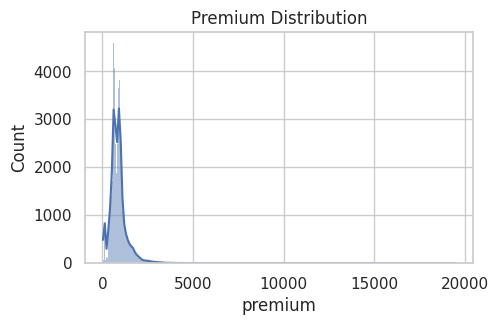


Description: Distribution of target variable (premium)
 Insight: Right skew → few customers pay very high premiums


In [31]:
plt.figure(figsize=(5,3))
sns.histplot(df["premium"], kde=True)
plt.title("Premium Distribution")
plt.show()

print("\nDescription: Distribution of target variable (premium)")
print(" Insight: Right skew → few customers pay very high premiums")

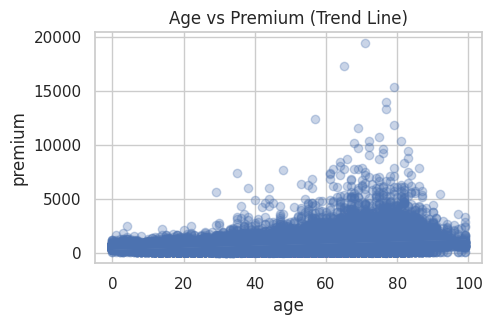


 Description: Shows trend between age and premium
Insight: Positive trend → premium increases with age


In [32]:
plt.figure(figsize=(5,3))
sns.regplot(x="age", y="premium", data=df, scatter_kws={"alpha":0.3})
plt.title("Age vs Premium (Trend Line)")
plt.show()

print("\n Description: Shows trend between age and premium")
print("Insight: Positive trend → premium increases with age")

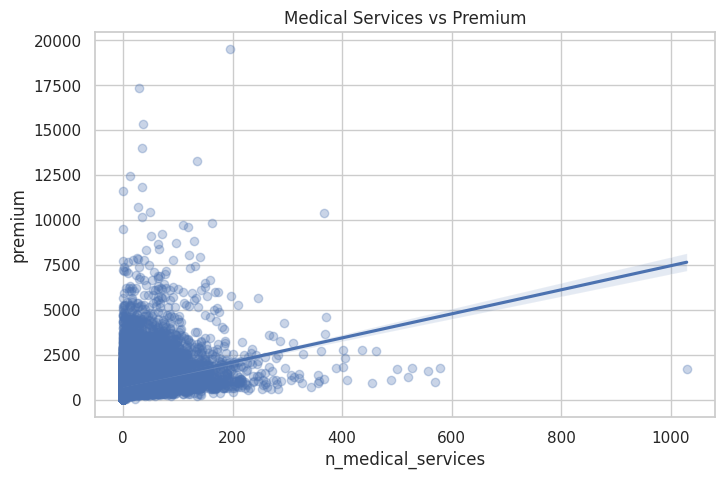


 Description: Medical usage vs premium
Insight: Higher usage → higher premium


In [33]:
plt.figure(figsize=(8,5))
sns.regplot(x="n_medical_services", y="premium", data=df, scatter_kws={"alpha":0.3})
plt.title("Medical Services vs Premium")
plt.show()

print("\n Description: Medical usage vs premium")
print("Insight: Higher usage → higher premium")

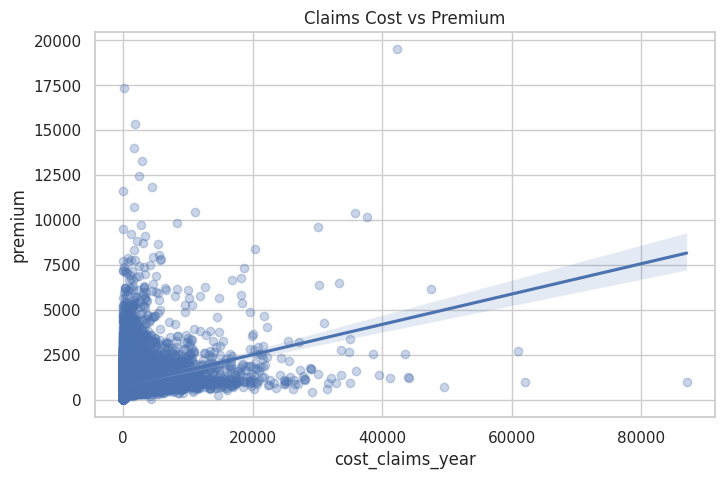


📌 Description: Claims history vs premium
💡 Insight: Strong relationship → key driver of premium


In [34]:
plt.figure(figsize=(8,5))
sns.regplot(x="cost_claims_year", y="premium", data=df, scatter_kws={"alpha":0.3})
plt.title("Claims Cost vs Premium")
plt.show()

print("\n Description: Claims history vs premium")
print(" Insight: Strong relationship → key driver of premium")

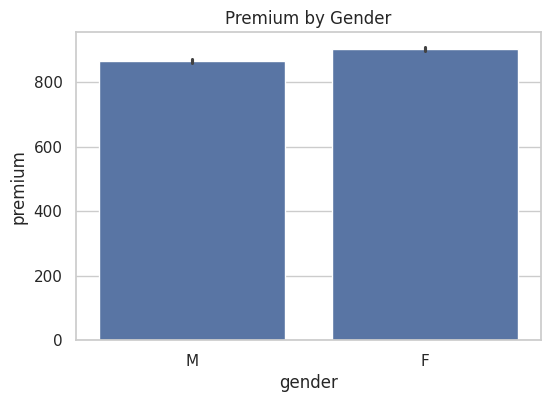


📌 Description: Premium comparison across gender
💡 Insight: Helps detect pricing bias or differences


In [37]:
plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="premium", data=df)
plt.title("Premium by Gender")
plt.show()

print("\n📌 Description: Premium comparison across gender")
print("💡 Insight: Helps detect pricing bias or differences")

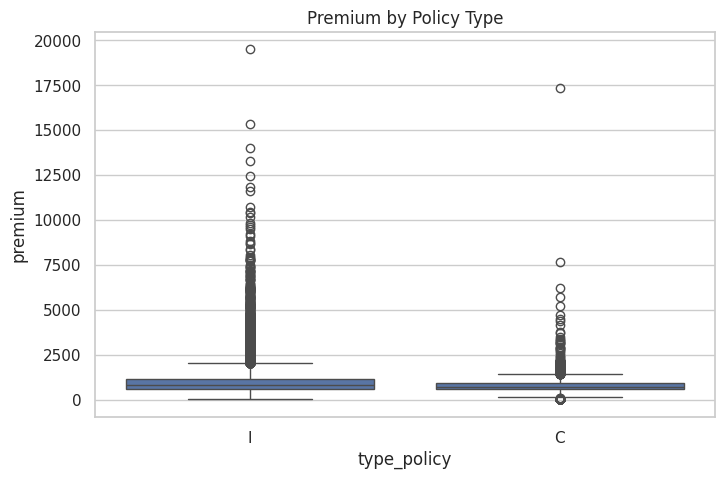


 Description: Premium variation across policy types
 Insight: Different products have different pricing strategies


In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x="type_policy", y="premium", data=df)
plt.title("Premium by Policy Type")
plt.show()

print("\n Description: Premium variation across policy types")
print(" Insight: Different products have different pricing strategies")

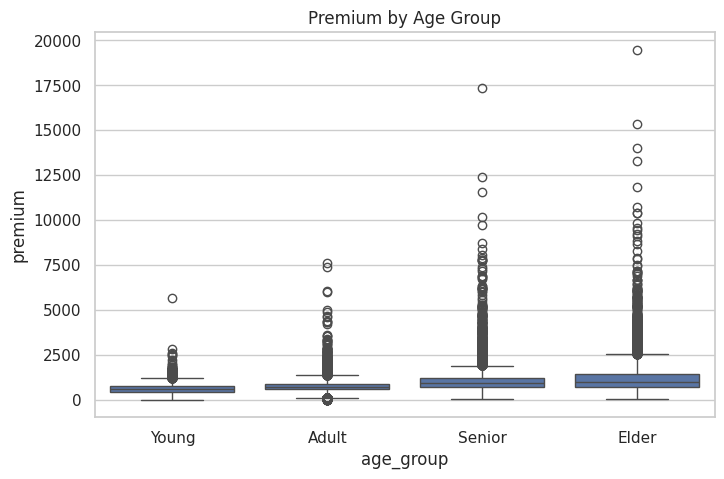


📌 Description: Customer segmentation by age
💡 Insight: Older groups pay higher premiums


In [ ]:
df["age_group"] = pd.cut(df["age"], bins=[0,30,50,70,100],
                        labels=["Young","Adult","Senior","Elder"])

plt.figure(figsize=(8,5))
sns.boxplot(x="age_group", y="premium", data=df)
plt.title("Premium by Age Group")
plt.show()

print("\n Description: Customer segmentation by age")
print(" Insight: Older groups pay higher premiums")

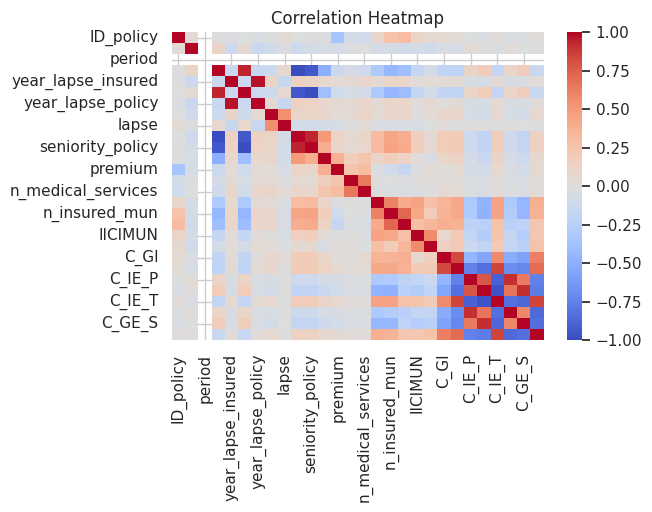


 Description: Relationship between numerical features
 Insight: Identify strong predictors of premium


In [44]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("\n Description: Relationship between numerical features")
print(" Insight: Identify strong predictors of premium")

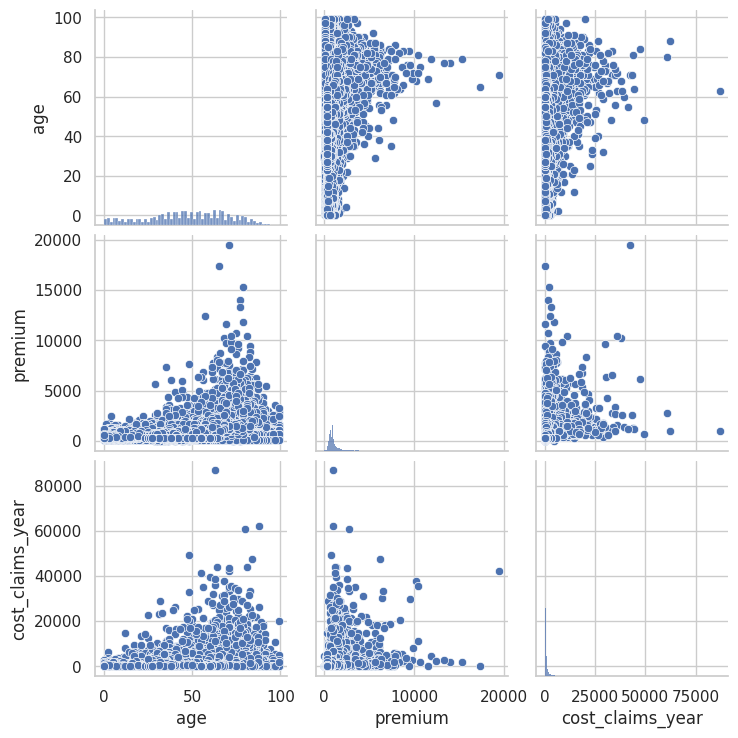


 Description:
Shows pairwise relationships between important variables


In [55]:
sns.pairplot(df[["age", "premium", "cost_claims_year"]])
plt.show()

print("\n Description:")
print("Shows pairwise relationships between important variables")

In [49]:
ct1 = pd.crosstab(df["gender"], df["type_policy"])

print("\n Cross Tab: Gender vs Policy Type")
display(ct1)

print("\n Description:")
print("Shows how policy types are distributed across gender")


 Cross Tab: Gender vs Policy Type


type_policy,C,I
gender,,
F,14543,20856
M,12270,17866



 Description:
Shows how policy types are distributed across gender


In [48]:
ct2 = pd.crosstab(df["age_group"], df["type_policy"])

print("\nCross Tab: Age Group vs Policy Type")
display(ct2)

print("\n Description:")
print("Shows which age group prefers which policy")


Cross Tab: Age Group vs Policy Type


type_policy,C,I
age_group,,
Young,5028,9991
Adult,7355,11972
Senior,8692,11149
Elder,5596,5268



 Description:
Shows which age group prefers which policy


In [50]:
pivot = pd.pivot_table(df,
                       values="premium",
                       index="age_group",
                       columns="gender",
                       aggfunc="mean")

print("\n📊 Pivot Table: Avg Premium by Age & Gender")
display(pivot)

print("\n📌 Description:")
print("Shows combined effect of age and gender on premium")


📊 Pivot Table: Avg Premium by Age & Gender


/tmp/ipykernel_326835/580459375.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df,


gender,F,M
age_group,,
Young,623.125137,615.946776
Adult,783.624715,740.303462
Senior,1033.085361,1023.380778
Elder,1212.529457,1232.774018



📌 Description:
Shows combined effect of age and gender on premium


In [52]:
ct3 = df.groupby("type_policy")["premium"].mean()

print("\n Average Premium by Policy Type:")
display(ct3)

print("\nDescription:")
print("Shows average premium per policy type")


 Average Premium by Policy Type:


type_policy
C    767.277533
I    966.943329
Name: premium, dtype: float64


Description:
Shows average premium per policy type


In [53]:
pivot = pd.pivot_table(df,
                       values="premium",
                       index="age_group",
                       columns="gender",
                       aggfunc="mean")

print("\n Pivot Table: Avg Premium by Age & Gender")
display(pivot)

print("\n Description:")
print("Shows combined effect of age and gender on premium")


 Pivot Table: Avg Premium by Age & Gender


/tmp/ipykernel_326835/3693121779.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df,


gender,F,M
age_group,,
Young,623.125137,615.946776
Adult,783.624715,740.303462
Senior,1033.085361,1023.380778
Elder,1212.529457,1232.774018



 Description:
Shows combined effect of age and gender on premium
